# Economic and Affordability Features

**Purpose.** ACS DP03 employment, commuting, occupation, industry, income, benefits, and health-insurance features.

This notebook is a read-only diagnostic consumer of the current `feature.*` layer. All transformations and canonical ACS mappings are owned by `src/cli/build_database.py`.

## Setup and current feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "housing_predict.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DB_PATH = ROOT / "data" / "housing_predict.duckdb"
if not DB_PATH.exists():
    raise FileNotFoundError("Run `python -m src.cli.build_database` from the project root first.")

con = duckdb.connect(str(DB_PATH), read_only=True)
FEATURE_TABLES = ['county_economic_annual']

available = {row[0] for row in con.execute(
    "SELECT table_name FROM information_schema.tables WHERE table_schema = 'feature'"
).fetchall()}
missing = sorted(set(FEATURE_TABLES) - available)
if missing:
    raise RuntimeError(
        f"Database is missing current feature tables {missing}. "
        "Run `python -m src.cli.build_database` to rebuild it."
    )

registry_available = "canonical_feature_registry" in available
if registry_available:
    placeholders = ", ".join("?" for _ in FEATURE_TABLES)
    source_tables = [{
        "county_economic_annual": "dp03",
        "county_social_annual": "dp02",
        "county_housing": "dp04",
    }.get(table) for table in FEATURE_TABLES]
    source_tables = [table for table in source_tables if table]
    if source_tables:
        source_placeholders = ", ".join("?" for _ in source_tables)
        registry = con.execute(
            f"SELECT feature_name, acs_table, unit, min(year) AS first_year, "
            f"max(year) AS last_year, count(*) AS mapped_years "
            f"FROM feature.canonical_feature_registry WHERE acs_table IN ({source_placeholders}) "
            f"GROUP BY 1,2,3 ORDER BY 2,1",
            source_tables,
        ).df()
    else:
        registry = pd.DataFrame(columns=["feature_name", "acs_table", "unit", "first_year", "last_year", "mapped_years"])
else:
    registry = pd.DataFrame()
display(registry)

,feature_name,acs_table,unit,first_year,last_year,mapped_years
0,agriculture_mining_industry_pct,dp03,percent,2010,2024,15
1,arts_hospitality_food_industry_pct,dp03,percent,2010,2024,15
2,construction_industry_pct,dp03,percent,2010,2024,15
3,drove_alone_to_work_pct,dp03,percent,2010,2024,15
4,education_health_social_services_industry_pct,dp03,percent,2010,2024,15
5,employed_pct,dp03,percent,2010,2024,15
6,finance_real_estate_industry_pct,dp03,percent,2010,2024,15
7,labor_force_pct,dp03,percent,2010,2024,15
8,management_business_science_arts_occupation_pct,dp03,percent,2010,2024,15
9,manufacturing_industry_pct,dp03,percent,2010,2024,15


## Table inventory and county-year grain

In [2]:
inventory = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    row_count, distinct_keys, min_year, max_year = con.execute(
        f"SELECT count(*), count(DISTINCT (county_fips, year)), min(year), max(year) FROM feature.{table}"
    ).fetchone()
    inventory.append({
        "feature_table": table,
        "rows": row_count,
        "distinct_county_years": distinct_keys,
        "duplicate_county_years": row_count - distinct_keys,
        "first_year": min_year,
        "last_year": max_year,
        "feature_columns": len(schema) - len({"county_fips", "year", "county_name"} & set(schema["column_name"])),
    })
inventory = pd.DataFrame(inventory)
display(inventory)
assert (inventory["duplicate_county_years"] == 0).all(), "Feature tables must be unique by county and year."

,feature_table,rows,distinct_county_years,duplicate_county_years,first_year,last_year,feature_columns
0,county_economic_annual,48312,48312,0,2010,2024,28


## Completeness by feature and year

In [3]:
completeness = []
identifier_columns = {"county_fips", "year", "county_name"}
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    for column in [column for column in columns if column not in identifier_columns]:
        quoted = '"' + column.replace('"', '""') + '"'
        rows = con.execute(
            f"SELECT year, count(*) AS rows, count({quoted}) AS nonnull_rows "
            f"FROM feature.{table} GROUP BY year ORDER BY year"
        ).df()
        rows["feature_table"] = table
        rows["feature_name"] = column
        rows["completeness_pct"] = 100 * rows["nonnull_rows"] / rows["rows"]
        completeness.append(rows)
completeness = pd.concat(completeness, ignore_index=True)
display(completeness.groupby(["feature_table", "feature_name"], as_index=False).agg(
    first_available_year=("year", lambda s: completeness.loc[s.index][completeness.loc[s.index, "nonnull_rows"] > 0]["year"].min()),
    mean_completeness_pct=("completeness_pct", "mean"),
    minimum_completeness_pct=("completeness_pct", "min"),
).sort_values(["feature_table", "mean_completeness_pct"]))

,feature_table,feature_name,first_available_year,mean_completeness_pct,minimum_completeness_pct
23,county_economic_annual,unemployment_rate_pct,2015,66.664596,0.000000
25,county_economic_annual,with_health_insurance_pct,2012,86.666667,0.000000
26,county_economic_annual,without_health_insurance_pct,2012,86.666667,0.000000
10,county_economic_annual,mean_cash_public_assistance_income_2024_usd,2010,95.752632,94.099379
15,county_economic_annual,mean_supplemental_security_income_2024_usd,2010,98.294455,97.330850
13,county_economic_annual,mean_retirement_income_2024_usd,2010,99.946184,99.875776
11,county_economic_annual,mean_commute_time_minutes,2010,99.977235,99.906890
16,county_economic_annual,median_household_income_2024_usd,2010,99.983443,99.937927
14,county_economic_annual,mean_social_security_income_2024_usd,2010,99.987581,99.968944
0,county_economic_annual,agriculture_mining_industry_pct,2010,99.997930,99.968944


## Distributions and range checks

In [4]:
summaries = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False, regex=True),
        "column_name",
    ].tolist()
    for column in [column for column in numeric if column != "year"]:
        q = '"' + column.replace('"', '""') + '"'
        values = con.execute(f"SELECT {q} FROM feature.{table} WHERE {q} IS NOT NULL").df().iloc[:, 0]
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        summaries.append({
            "feature_table": table, "feature_name": column, "count": len(values),
            "min": values.min(), "median": values.median(), "mean": values.mean(), "max": values.max(),
            "iqr_outliers": int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()),
            "outside_percent_range": int(((values < 0) | (values > 100)).sum()) if column.endswith("_pct") else np.nan,
        })
summaries = pd.DataFrame(summaries)
display(summaries)
assert summaries["outside_percent_range"].fillna(0).eq(0).all(), "Percentage feature outside [0, 100]."

,feature_table,feature_name,count,min,median,mean,max,iqr_outliers,outside_percent_range
0,county_economic_annual,labor_force_pct,48311,11.600000,59.600000,58.731583,97.700000,735,0.0
1,county_economic_annual,employed_pct,48311,11.000000,55.300000,54.546300,97.700000,708,0.0
2,county_economic_annual,unemployment_rate_pct,32207,0.000000,5.300000,5.958552,40.900000,1453,0.0
3,county_economic_annual,drove_alone_to_work_pct,48311,3.200000,80.000000,78.568287,99.300000,2244,0.0
4,county_economic_annual,public_transit_to_work_pct,48311,0.000000,0.300000,0.875738,61.800000,5315,0.0
5,county_economic_annual,walked_to_work_pct,48311,0.000000,2.300000,3.176430,82.000000,2915,0.0
6,county_economic_annual,worked_from_home_pct,48311,0.000000,4.800000,5.791004,49.200000,2550,0.0
7,county_economic_annual,mean_commute_time_minutes,48301,4.300000,23.400000,23.640606,59.500000,747,NaN
8,county_economic_annual,management_business_science_arts_occupation_pct,48311,2.600000,31.100000,32.057533,83.300000,1396,0.0
9,county_economic_annual,service_occupation_pct,48311,0.000000,17.500000,17.900108,46.400000,1660,0.0


## Correlation and redundancy

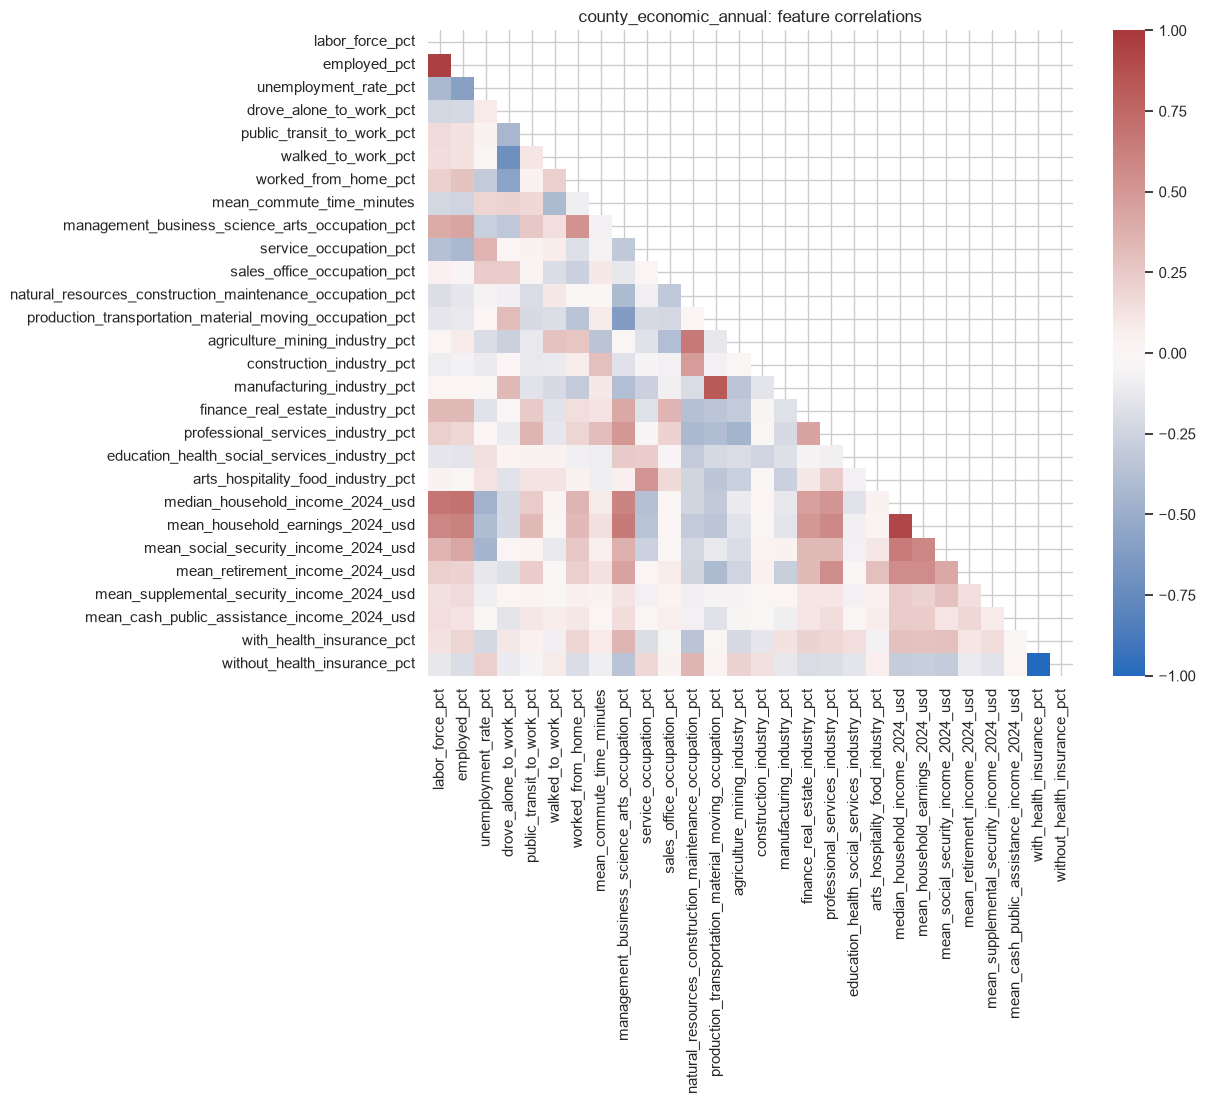

,feature_a,feature_b,correlation,abs_correlation
782,without_health_insurance_pct,with_health_insurance_pct,-1.000000,1.000000
28,employed_pct,labor_force_pct,0.954635,0.954635
608,mean_household_earnings_2024_usd,median_household_income_2024_usd,0.927136,0.927136
432,manufacturing_industry_pct,production_transportation_material_moving_occu...,0.824142,0.824142
143,walked_to_work_pct,drove_alone_to_work_pct,-0.713485,0.713485
561,median_household_income_2024_usd,employed_pct,0.701917,0.701917
560,median_household_income_2024_usd,labor_force_pct,0.679448,0.679448
375,agriculture_mining_industry_pct,natural_resources_construction_maintenance_occ...,0.658013,0.658013
596,mean_household_earnings_2024_usd,management_business_science_arts_occupation_pct,0.656164,0.656164
636,mean_social_security_income_2024_usd,median_household_income_2024_usd,0.647670,0.647670


In [5]:
for table in FEATURE_TABLES:
    frame = con.execute(f"SELECT * FROM feature.{table}").df()
    numeric = frame.select_dtypes(include=np.number).drop(columns=["year"], errors="ignore")
    if numeric.shape[1] < 2:
        continue
    corr = numeric.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(max(8, 0.45 * len(corr)), max(6, 0.4 * len(corr))))
    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"{table}: feature correlations")
    plt.tight_layout()
    plt.show()

    pairs = corr.where(~mask).stack().rename("correlation").reset_index()
    pairs.columns = ["feature_a", "feature_b", "correlation"]
    display(pairs.assign(abs_correlation=pairs["correlation"].abs()).sort_values("abs_correlation", ascending=False).head(20))

## Temporal coverage and trends

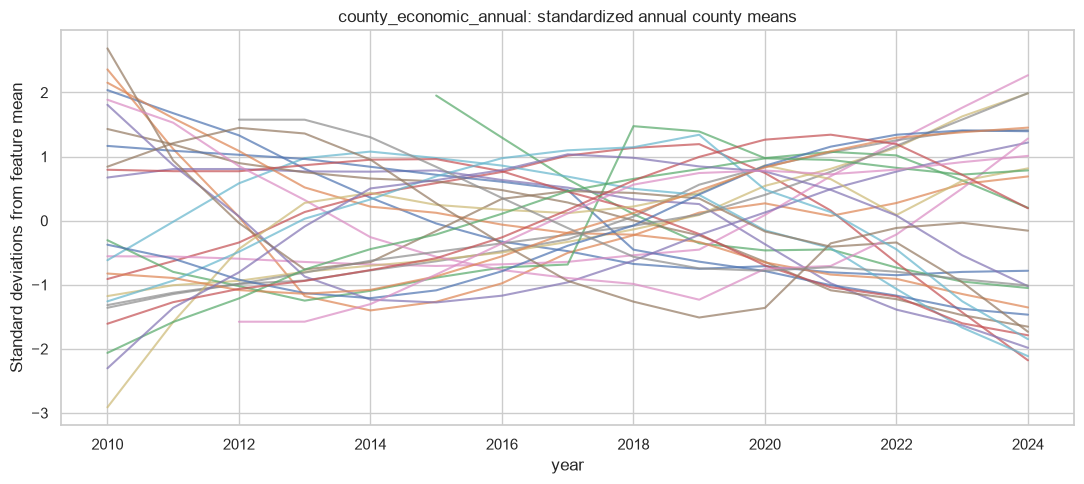

,year,labor_force_pct,employed_pct,unemployment_rate_pct,drove_alone_to_work_pct,public_transit_to_work_pct,walked_to_work_pct,worked_from_home_pct,mean_commute_time_minutes,management_business_science_arts_occupation_pct,service_occupation_pct,sales_office_occupation_pct,natural_resources_construction_maintenance_occupation_pct,production_transportation_material_moving_occupation_pct,agriculture_mining_industry_pct,construction_industry_pct,manufacturing_industry_pct,finance_real_estate_industry_pct,professional_services_industry_pct,education_health_social_services_industry_pct,arts_hospitality_food_industry_pct,median_household_income_2024_usd,mean_household_earnings_2024_usd,mean_social_security_income_2024_usd,mean_retirement_income_2024_usd,mean_supplemental_security_income_2024_usd,mean_cash_public_assistance_income_2024_usd,with_health_insurance_pct,without_health_insurance_pct
0,2010,60.742192,55.838622,NaN,77.617231,0.958243,3.519249,4.879975,22.864328,30.005092,17.618597,22.854890,13.496740,16.024961,6.804440,8.019497,12.631729,4.766439,6.367929,22.199069,7.751319,62739.805245,80768.826544,21196.969414,26303.555639,11250.607316,4015.509586,NaN,NaN
1,2011,60.386992,55.158802,NaN,77.909655,0.974449,3.461347,4.873176,22.986340,30.300869,17.892580,22.746849,13.283297,15.778237,6.796243,7.736759,12.337380,4.738218,6.458460,22.596492,7.827817,62225.142033,80513.118228,21533.865580,26612.552872,11552.976553,4121.796896,NaN,NaN
2,2012,60.045700,54.579230,NaN,78.212170,0.974511,3.391773,4.817106,23.077212,30.421515,18.166284,22.658460,13.086091,15.667743,6.795964,7.497082,12.173331,4.684974,6.523657,22.937131,7.934120,61445.393672,79814.485620,21790.694926,26802.537519,11730.592782,4190.917963,85.043247,14.956753
3,2013,59.532226,53.902173,NaN,78.709935,0.969947,3.357311,4.733996,23.106954,30.665911,18.345669,22.566687,12.866656,15.554455,6.830177,7.215306,12.051226,4.643247,6.605806,23.152065,8.056349,60951.093431,79601.461798,22105.725951,26917.118505,11960.244992,4165.433698,85.045110,14.954890
4,2014,59.086242,53.779658,NaN,79.000807,0.969441,3.334006,4.670311,23.197640,30.831460,18.392267,22.393230,12.751056,15.631056,6.861739,7.106894,12.070714,4.597609,6.692826,23.198602,8.127578,60762.624489,79827.821221,22328.671691,27072.007060,12150.374290,4047.552991,85.683758,14.316273
5,2015,58.688602,53.853509,8.094441,79.181925,0.971832,3.323509,4.631770,23.278758,30.990621,18.346398,22.215807,12.714099,15.733385,6.865031,7.093975,12.152422,4.573509,6.758137,23.142826,8.212702,61052.297710,80604.592673,22488.268268,27241.928783,12192.011404,3850.454088,86.759472,13.240559
6,2016,58.408820,54.011149,7.376739,79.363478,0.953478,3.290807,4.673665,23.368882,31.191522,18.292609,22.060466,12.642919,15.812702,6.795963,7.125621,12.236801,4.557236,6.820342,23.120093,8.279689,61758.372414,81761.699576,22714.475752,27540.131478,12242.243122,3667.653532,87.890000,12.110000
7,2017,58.262764,54.271118,6.665590,79.630963,0.938975,3.244472,4.736894,23.474534,31.479814,18.214286,21.878944,12.592360,15.835745,6.679783,7.187919,12.257329,4.547422,6.883354,23.104255,8.308727,62700.645117,83121.731994,22960.730232,27930.749861,12320.922374,3500.074996,88.981708,11.018292
8,2018,58.065766,54.421870,6.071295,79.756042,0.916620,3.177509,4.905934,23.677595,31.819261,18.126996,20.557999,12.582355,16.913234,6.578254,7.290059,12.252190,4.540199,6.948835,23.135290,8.320099,63450.354823,84249.492646,23094.514568,28353.694761,12303.605892,3406.165084,90.027484,9.972516
9,2019,57.990714,54.615186,5.572764,79.817081,0.907516,3.121460,5.049876,23.961727,32.214161,18.083447,20.291739,12.538665,16.871553,6.438012,7.410217,12.237733,4.520807,7.032422,23.197050,8.366087,64598.712669,85557.373630,23201.196226,28692.434096,12260.522507,3334.490280,90.450373,9.549627


In [6]:
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric = schema.loc[schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT", case=False), "column_name"].tolist()
    numeric = [column for column in numeric if column != "year"]
    if not numeric:
        continue
    expressions = ", ".join(f'avg("{column}") AS "{column}"' for column in numeric)
    annual = con.execute(f"SELECT year, {expressions} FROM feature.{table} GROUP BY year ORDER BY year").df()
    normalized = annual.set_index("year").apply(lambda s: (s - s.mean()) / s.std() if s.std() else 0)
    fig, ax = plt.subplots(figsize=(11, 5))
    normalized.plot(ax=ax, legend=False, alpha=0.7)
    ax.set_title(f"{table}: standardized annual county means")
    ax.set_ylabel("Standard deviations from feature mean")
    plt.tight_layout()
    plt.show()
    display(annual)

con.close()

## Interpretation notes

- ACS values are five-year estimates associated with their release year. Adjacent years therefore contain overlapping survey periods. Five-year estimates are favored over one-year estimates in this project because the former offers complete annual data over the time period defined in the project's scope, while the latter does not.
- Monetary ACS features and the housing target are expressed in 2024 dollars.
- A null before a feature's `first_year` can indicate that ACS had not yet published a reconciled definition.
- `target_median_owner_occupied_home_value_2024_usd` is the official DP04 median, because DP04 does not publish a county average housing-unit value.
- The canonical registry and transactional build are the authority for cross-year compatibility.